# S2 | V3 Question Sampling

Builds the V3 study question set:
- **Base:** 113 valid V2 questions carried over
- **Addition:** 11 new yesno questions for underrepresented ent groups
- **Output:** `experiment/s2_v3/s3.csv` + `s3_question.json`

In [4]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/vlm/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


In [5]:
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict

mapper = VQAAnswerMapper()

# ── Group mappings ──────────────────────────────────────────────────────────
ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',    'place': 'scene',   'vehicle': 'scene',
    'other': 'other',   'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}

# ── Load control + inst_blind for all 8 complete models ─────────────────────
# Signal score is based on inst_blind (no image + instruction) — the condition
# used in the human study. High inst_blind accuracy = strong linguistic prior.
print('Loading control and inst_blind logits for 8 complete models...')

acc_by      = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, control]
acc_inst_by = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, inst_blind]
out_sets      = defaultdict(set)   # answer diversity across CTs+models (control)
out_sets_inst = defaultdict(set)   # answer diversity (inst_blind)
flat_ck = {}

for m in COMPLETE_MODELS:
    # control
    path = f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl'
    n = 0
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            if qid not in flat_ck:
                flat_ck[qid] = {ex.get(ct,'').strip().lower() for ct in CONTROL_TYPES if ex.get(ct)}
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets[qid].add(out.lower())
            n += 1
    # inst_blind
    path_inst = f'{RESULTS_DIR}/{m}/vqa_1k_control_inst_blind.jsonl'
    ni = 0
    with open(path_inst) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_inst_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets_inst[qid].add(out.lower())
            ni += 1
    print(f'  {m}: control={n}  inst_blind={ni}')

print(f'\nTotal questions with control signals: {len(acc_by)}')
print(f'Total questions with inst_blind signals: {len(acc_inst_by)}')


Loading control and inst_blind logits for 8 complete models...
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  InternVL3_5-1B: control=1000  inst_blind=1000
  InternVL3_5-2B: control=1000  inst_blind=1000
  InternVL3_5-8B: control=1000  inst_blind=1000
  Qwen3-VL-2B-Instruct: control=1000  inst_blind=1000
  Qwen3-VL-4B-Instruct: control=1000  inst_blind=1000
  llava-1.5-7b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-13b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-7b-hf: control=1000  inst_blind=1000

Total questions with control signals: 1000
Total questions with inst_blind signals: 1000


In [6]:
# ── Build signal_df + merged semantics ──────────────────────────────────────
# Signal score = 0.7·inst_blind_acc_orig + 0.3·acc_range(ctrl)
# Ranking is purely by signal_score within each 3x3 cell.

sig_rows = []
all_qids = set(acc_by.keys()) & set(acc_inst_by.keys())
for qid in all_qids:
    ct_dict      = acc_by[qid]
    ct_dict_inst = acc_inst_by[qid]

    accs      = {ct: float(np.mean(v)) for ct, v in ct_dict.items() if v}
    vals_v    = [accs.get(ct, np.nan) for ct in CONTROL_TYPES]
    vals_v    = [v for v in vals_v if not np.isnan(v)]
    acc_orig  = accs.get('question', np.nan)
    acc_pron  = accs.get('pronominalized', np.nan)
    acc_range = acc_orig - acc_pron if not (np.isnan(acc_orig) or np.isnan(acc_pron)) else np.nan
    acc_std   = float(np.std(vals_v)) if len(vals_v) > 1 else np.nan
    n_unique  = len(out_sets[qid])
    is_flat   = len(flat_ck.get(qid, set())) <= 1

    accs_inst      = {ct: float(np.mean(v)) for ct, v in ct_dict_inst.items() if v}
    inst_acc_orig  = accs_inst.get('question', np.nan)
    inst_acc_pron  = accs_inst.get('pronominalized', np.nan)
    inst_acc_range = (inst_acc_orig - inst_acc_pron
                      if not (np.isnan(inst_acc_orig) or np.isnan(inst_acc_pron)) else np.nan)
    n_unique_inst  = len(out_sets_inst[qid])

    sig_rows.append({
        'question_id':        qid,
        'acc_original':       acc_orig,
        'acc_pronominalized': acc_pron,
        'acc_range':          acc_range,
        'acc_std':            acc_std,
        'n_unique':           n_unique,
        'is_flat':            is_flat,
        'inst_acc_orig':      inst_acc_orig,
        'inst_acc_range':     inst_acc_range,
        'n_unique_inst':      n_unique_inst,
    })

sig_df = pd.DataFrame(sig_rows)

# Use all 9 original ent types (no collapse); op grouped into attr vs other_op
OP3  = {'attr':'attr',
        'count':'other_op', 'exist':'other_op', 'spat':'other_op',
        'ident':'other_op', 'act':'other_op', 'text':'other_op',
        'know':'other_op', 'comp':'other_op', 'cause':'other_op',
        'temp':'other_op', 'other':'other_op'}

full_df = sig_df.merge(sem_df[['question_id','ent','op','w','ans']], on='question_id')
full_df['ent_grp'] = full_df['ent']                    # 9 types, no collapse
full_df['op_grp']  = full_df['op'].map(OP3).fillna('other_op')
full_df['cell']    = full_df['ent_grp'] + '|' + full_df['op_grp']

nf = full_df[~full_df['is_flat']].copy()

# ── Exclude S1 (ACL submission) question IDs ────────────────────────────
s1_csv = pd.read_csv('/home/david/Desktop/yuna/HPA/analysis/session1/csv/human_vqa.csv')
S1_QIDS = set(s1_csv['question_id'].astype(int).tolist())
n_before = len(nf)
nf = nf[~nf['question_id'].isin(S1_QIDS)].copy()
print(f'S1 exclusion: removed {n_before - len(nf)} questions ({len(S1_QIDS)} in S1 pool)')
print(f'Non-flat pool after S1 exclusion: {len(nf)}')

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
nf['signal_score'] = (
    0.7 * norm(nf['inst_acc_orig'].fillna(0))
  + 0.3 * norm(nf['acc_range'].fillna(0))
)

print(f'Non-flat pool: {len(nf)} / {len(full_df)}')
# print(f'Signal score:       mean={nf["signal_score"].mean():.3f}')
# print(f'inst_blind acc orig: mean={nf["inst_acc_orig"].mean():.3f}')
# print(f'acc_range (ctrl):    mean={nf["acc_range"].mean():.3f}')
print(f'\n9x2 pool sizes (attr vs other_op; all ent types):')
print(nf.groupby(["ent_grp","op_grp"]).size().unstack(fill_value=0))


S1 exclusion: removed 340 questions (374 in S1 pool)
Non-flat pool after S1 exclusion: 585
Non-flat pool: 585 / 1000

9x2 pool sizes (attr vs other_op; all ent types):
op_grp   attr  other_op
ent_grp                
animal     22        40
food       22        26
object    107       108
other      13        22
person     48        88
place      11        22
product     2         7
text        2        14
vehicle    17        14


---

## V3 Sampling — V2 Carryover + Yesno Supplement

**Design:**
- **Base:** all 113 valid V2 questions carried over (3 excluded: flat or duplicate)
- **Addition:** 11 new yesno questions for underrepresented ent groups (other/place/vehicle/text/product → target 4 each, capped by pool)
- **Ranking:** new additions ranked by signal score within each ent group
- **Korean:** translations reused from V2 where available; new questions left blank for manual translation
- **Exclusions:** S1 questions · duplicate English question text · flat questions

**Output:** `experiment/s2_v3/s3.csv` + `s3_question.json`

In [7]:
# ── V3: Load V2 + build exclusion-filtered pool ─────────────────────────────
import re
from pathlib import Path

CTRL_PATH  = Path('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl')
SEM_PATH   = Path('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')
S1_PATH    = Path('/home/david/Desktop/yuna/HPA/analysis/session1/csv/human_vqa.csv')
V2Q_PATH   = Path('/home/david/Desktop/yuna/HPA/experiment/s2_v2/s2_question.json')
V2CSV_PATH = Path('/home/david/Desktop/yuna/HPA/experiment/s2_v2/s2.csv')

ctrl_df  = pd.DataFrame([json.loads(l) for l in open(CTRL_PATH)])
sem_df3  = pd.read_json(SEM_PATH, lines=True)
v2_study = pd.DataFrame(json.load(open(V2Q_PATH)))
v2_csv   = pd.read_csv(V2CSV_PATH)

CONTROL_TYPES_ALL = ['question','deictic_removed','object_removed','weaker_object','pronominalized']

# ── 1. Build exclusion sets ───────────────────────────────────────────────────
s1_qids = set(pd.read_csv(S1_PATH)['question_id'].astype(int))

ctrl_df['q_norm'] = ctrl_df['question'].str.lower().str.strip()
dup_qids = set(ctrl_df[ctrl_df.duplicated('q_norm', keep='first')]['question_id'])

def is_flat(qid):
    row = ctrl_df[ctrl_df.question_id == qid]
    if row.empty: return False
    row = row.iloc[0]
    texts = [str(row.get(ct, '')).strip().lower() for ct in CONTROL_TYPES_ALL]
    return len(set(t for t in texts if t)) <= 1

flat_qids = {qid for qid in sem_df3['question_id'] if is_flat(qid)}

excl_ids = s1_qids | dup_qids | flat_qids

# ── 2. V2 carryover: all valid V2 questions ───────────────────────────────────
v2_ids     = set(v2_study['question_id'])
v2_yn_ids  = set(v2_study[v2_study['answer_type'] == 'yesno']['question_id'])
valid_v2   = v2_ids - excl_ids

v2_carry = sem_df3[sem_df3['question_id'].isin(valid_v2)].copy()
excluded_v2 = v2_ids - valid_v2
print(f'V2 carryover: {len(v2_carry)} questions (excluded: {len(excluded_v2)})')
if excluded_v2:
    ex = v2_study[v2_study['question_id'].isin(excluded_v2)][['question_id','question_en','answer_type']]
    print('  Excluded:', ex.to_string(index=False))

# ── 3. Signal score for new additions ────────────────────────────────────────
sig3 = sig_df[['question_id','acc_original','acc_pronominalized','acc_range',
               'acc_std','n_unique','inst_acc_orig','inst_acc_range']].copy()

def norm3(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Pool for new yesno additions: exclude S1, dups, flats, AND V2 questions
new_pool = sem_df3[~sem_df3['question_id'].isin(excl_ids | v2_ids)].copy()
new_pool = new_pool.merge(sig3, on='question_id', how='left')
new_pool['signal_score'] = (
    0.7 * norm3(new_pool['inst_acc_orig'].fillna(0))
  + 0.3 * norm3(new_pool['acc_range'].fillna(0))
)

ENT_ORDER = ['object','person','animal','food','place','vehicle','other','text','product']
print(f'\nNew pool (excl V2): {len(new_pool)} questions')

# V2 yesno counts by ent for gap calculation
v2_carry_sem = sem_df3[sem_df3['question_id'].isin(valid_v2)].copy()
v2_carry_meta = v2_study[v2_study['question_id'].isin(valid_v2)][['question_id','answer_type']].copy()
v2_carry_sem = v2_carry_sem.merge(v2_carry_meta, on='question_id', how='left')
v2_yn_carry  = v2_carry_sem[v2_carry_sem['answer_type'] == 'yesno']
print('\nV2 carryover by ent:')
print(v2_carry_sem['ent'].value_counts().reindex(ENT_ORDER).fillna(0).astype(int).to_string())
print('\nV2 yesno by ent:')
print(v2_yn_carry['ent'].value_counts().reindex(ENT_ORDER).fillna(0).astype(int).to_string())

V2 carryover: 113 questions (excluded: 3)
  Excluded:  question_id                     question_en answer_type
   362229001           Are the flowers real?       yesno
    83277003          What is the man doing?        text
   254732011 How many planes are in the air?        text

New pool (excl V2): 457 questions

V2 carryover by ent:
ent
object     27
person     26
animal     17
food       16
place       5
vehicle     4
other       9
text        4
product     5

V2 yesno by ent:
ent
object     4
person     6
animal     5
food       5
place      2
vehicle    1
other      2
text       0
product    0


In [8]:
# ── V3: Select new yesno additions by signal score ───────────────────────────
# Target: 4 yesno per ent for underrepresented groups (other/place/vehicle/text/product)
# New additions only — V2 yesno are already carried over

TARGET_YN_GROUPS = ['other', 'place', 'vehicle', 'text', 'product']
yn_new_pool = new_pool[new_pool['w'] == 'yesno']

additions = []
yn_add_summary = {}
for ent in TARGET_YN_GROUPS:
    have = int((v2_yn_carry['ent'] == ent).sum())
    avail = yn_new_pool[yn_new_pool['ent'] == ent].sort_values('signal_score', ascending=False)
    n_add = min(max(0, 4 - have), len(avail))
    yn_add_summary[ent] = {'have': have, 'add': n_add, 'pool': len(avail)}
    additions.append(avail.head(n_add))
    print(f'  {ent:10s}: have={have}, adding={n_add} (pool={len(avail)})')

new_yn_df = pd.concat(additions) if additions else pd.DataFrame()
print(f'\nNew yesno additions: {len(new_yn_df)}')

# ── V3 final sample ───────────────────────────────────────────────────────────
# Merge signal scores onto v2 carryover
v2_carry_full = v2_carry_sem.merge(sig3, on='question_id', how='left')
v2_carry_full['signal_score'] = (
    0.7 * norm3(v2_carry_full['inst_acc_orig'].fillna(0))
  + 0.3 * norm3(v2_carry_full['acc_range'].fillna(0))
)

sampled_v3 = pd.concat([v2_carry_full, new_yn_df], ignore_index=True)
sampled_v3 = sampled_v3.drop_duplicates('question_id').reset_index(drop=True)

print(f'\n=== V3 sample: {len(sampled_v3)} questions ===')
print(f'  V2 carryover: {len(v2_carry_full)}')
print(f'  New additions: {len(new_yn_df)}')
print()
print('Ent distribution:')
print(sampled_v3['ent'].value_counts().reindex(ENT_ORDER).fillna(0).astype(int).to_string())
print()
OP3 = {'attr':'attr','count':'other_op','exist':'other_op','spat':'other_op',
       'ident':'other_op','act':'other_op','text':'other_op','know':'other_op',
       'comp':'other_op','cause':'other_op','temp':'other_op','other':'other_op'}
sampled_v3['op_grp'] = sampled_v3['op'].map(OP3).fillna('other_op')
print('Ent × op_grp:')
print(sampled_v3.groupby(['ent','op_grp']).size().unstack(fill_value=0).reindex(
    [e for e in ENT_ORDER if e in sampled_v3['ent'].values]).to_string())
print()
yn_total = (sampled_v3['w'] == 'yesno').sum()
print(f'Yesno total: {yn_total}')
print('Yesno by ent:')
print(sampled_v3[sampled_v3['w']=='yesno']['ent'].value_counts().reindex(ENT_ORDER).fillna(0).astype(int).to_string())
print()
print('Question-word distribution:')
print(sampled_v3['w'].value_counts().to_string())

  other     : have=2, adding=2 (pool=14)
  place     : have=2, adding=2 (pool=14)
  vehicle   : have=1, adding=3 (pool=9)
  text      : have=0, adding=2 (pool=2)
  product   : have=0, adding=2 (pool=2)

New yesno additions: 11

=== V3 sample: 124 questions ===
  V2 carryover: 113
  New additions: 11

Ent distribution:
ent
object     27
person     26
animal     17
food       16
place       7
vehicle     7
other      11
text        6
product     7

Ent × op_grp:
op_grp   attr  other_op
ent                    
object     11        16
person     10        16
animal      5        12
food        5        11
place       2         5
vehicle     4         3
other       3         8
text        2         4
product     2         5

Yesno total: 36
Yesno by ent:
ent
object     4
person     6
animal     5
food       5
place      4
vehicle    4
other      4
text       2
product    2

Question-word distribution:
w
what        51
yesno       36
how_many    22
where        6
which        5
how_old      

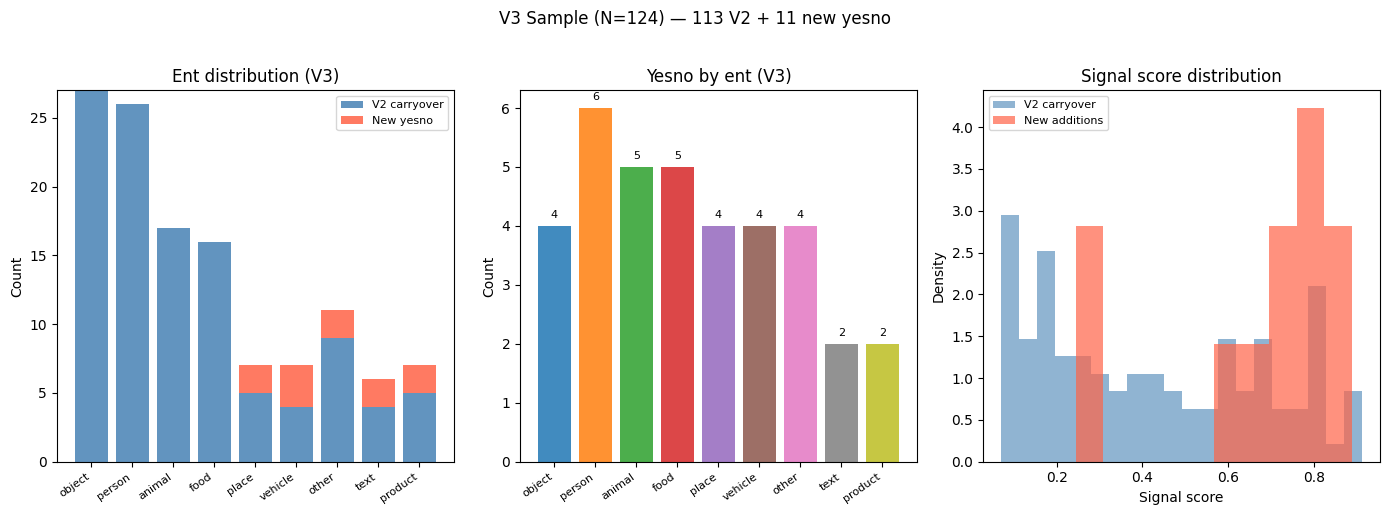

In [9]:
# ── V3: Visualise sample distribution ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ent_present = [e for e in ENT_ORDER if e in sampled_v3['ent'].values]
ENT_COLORS3 = plt.get_cmap('tab10')

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# Left: ent bar (V2 carryover vs new)
ax0 = fig.add_subplot(gs[0])
v2_ent = sampled_v3[sampled_v3['question_id'].isin(valid_v2)]['ent'].value_counts().reindex(ENT_ORDER).fillna(0)
new_ent = sampled_v3[~sampled_v3['question_id'].isin(valid_v2)]['ent'].value_counts().reindex(ENT_ORDER).fillna(0)
x = range(len(ENT_ORDER))
ax0.bar(x, v2_ent.values, color='steelblue', alpha=0.85, label='V2 carryover')
ax0.bar(x, new_ent.values, bottom=v2_ent.values, color='tomato', alpha=0.85, label='New yesno')
ax0.set_xticks(x); ax0.set_xticklabels(ENT_ORDER, rotation=35, ha='right', fontsize=8)
ax0.set_title('Ent distribution (V3)'); ax0.set_ylabel('Count'); ax0.legend(fontsize=8)

# Middle: yesno by ent
ax1 = fig.add_subplot(gs[1])
yn_by_ent = sampled_v3[sampled_v3['w']=='yesno']['ent'].value_counts().reindex(ENT_ORDER).fillna(0)
bars = ax1.bar(range(len(ENT_ORDER)), yn_by_ent.values,
               color=[ENT_COLORS3(i) for i in range(len(ENT_ORDER))], alpha=0.85)
ax1.set_xticks(range(len(ENT_ORDER))); ax1.set_xticklabels(ENT_ORDER, rotation=35, ha='right', fontsize=8)
ax1.set_title('Yesno by ent (V3)'); ax1.set_ylabel('Count')
for bar, v in zip(bars, yn_by_ent.values):
    if v > 0: ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, str(int(v)), ha='center', va='bottom', fontsize=8)

# Right: signal score distribution
ax2 = fig.add_subplot(gs[2])
ax2.hist(sampled_v3[sampled_v3['question_id'].isin(valid_v2)]['signal_score'].dropna(),
         bins=20, alpha=0.6, color='steelblue', label='V2 carryover', density=True)
if len(new_yn_df) > 0:
    ax2.hist(new_yn_df['signal_score'].dropna(),
             bins=10, alpha=0.7, color='tomato', label='New additions', density=True)
ax2.set_xlabel('Signal score'); ax2.set_ylabel('Density')
ax2.set_title('Signal score distribution'); ax2.legend(fontsize=8)

plt.suptitle(f'V3 Sample (N={len(sampled_v3)}) — 113 V2 + {len(new_yn_df)} new yesno', y=1.02)
plt.tight_layout(); plt.show()

In [10]:
# ── V3: Save s3.csv + s3_question.json + variant JSONs ──────────────────────
import os
OUT_DIR = Path('/home/david/Desktop/yuna/HPA/experiment/s2_v3')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── s3.csv ────────────────────────────────────────────────────────────────────
save_cols = [
    'question_id', 'ent', 'op', 'op_grp', 'w',
    'acc_original', 'acc_pronominalized', 'acc_range', 'acc_std', 'n_unique',
    'signal_score', 'inst_acc_orig', 'inst_acc_range',
]
final_cols = [c for c in save_cols if c in sampled_v3.columns]
sampled_v3[final_cols].to_csv(OUT_DIR / 's3.csv', index=False)
print(f'Saved s3.csv ({len(sampled_v3)} rows)')

# ── Load V2 variant lookups for Korean translations ───────────────────────────
V2_DIR = Path('/home/david/Desktop/yuna/HPA/experiment/s2_v2')
v2_q_map  = {x['question_id']: x for x in json.load(open(V2_DIR / 's2_question.json'))}
v2_pr_map = {x['question_id']: x for x in json.load(open(V2_DIR / 's2_pronominalized.json'))}
v2_wo_map = {x['question_id']: x for x in json.load(open(V2_DIR / 's2_weaker_object.json'))}

# ── Load control variant texts ────────────────────────────────────────────────
ctrl_map = {r['question_id']: r for r in
            [json.loads(l) for l in open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl')]}

def make_records(sampled, variant_label, v2_map, ctrl_field):
    """Build study JSON records for one variant."""
    records = []
    for i, row in sampled.iterrows():
        qid = int(row['question_id'])
        ans_type = 'yesno' if row.get('w') == 'yesno' else 'text'
        if qid in v2_map:
            ref = v2_map[qid]
            q_en = ref['question_en']
            q_kr = ref['question_kr']
        else:
            # New question — get English from control file, Korean needs manual translation
            ctrl = ctrl_map.get(qid, {})
            q_en = str(ctrl.get(ctrl_field, '')).strip()
            q_kr = ''
        records.append({
            'id':           i + 1,
            'question_id':  qid,
            'variant':      variant_label,
            'question_en':  q_en,
            'question_kr':  q_kr,
            'answer_type':  ans_type,
            'options':      None,
            'display_order': 0,
        })
    return records

# ── Generate and save all three variant files ─────────────────────────────────
variants = [
    ('C', 's3_question.json',      v2_q_map,  'question'),
    ('B', 's3_weaker_object.json', v2_wo_map, 'weaker_object'),
    ('A', 's3_pronominalized.json',v2_pr_map, 'pronominalized'),
]

for label, fname, v2_map, ctrl_field in variants:
    records = make_records(sampled_v3, label, v2_map, ctrl_field)
    with open(OUT_DIR / fname, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    missing_kr = sum(1 for r in records if not r['question_kr'])
    print(f'Saved {fname} ({len(records)} questions, {missing_kr} need KR translation)')

# ── Summary ───────────────────────────────────────────────────────────────────
from_v2 = sampled_v3['question_id'].isin(valid_v2).sum()
new_q   = len(sampled_v3) - from_v2
yn_q    = (sampled_v3['w'] == 'yesno').sum()
print(f'\nV3 summary:')
print(f'  Total:           {len(sampled_v3)}')
print(f'  From V2:         {from_v2}')
print(f'  New (yesno):     {new_q}')
print(f'  Yesno total:     {yn_q}')
print(f'  Need KR (new):   {new_q} questions × 3 variants = {new_q*3} strings')
print(f'\nStudy burden: {len(sampled_v3)} Qs × 3 variants × 25 raters = {len(sampled_v3)*3*25:,} responses')

Saved s3.csv (124 questions) → /home/david/Desktop/yuna/HPA/experiment/s2_v3/s3.csv
Saved s3_question.json (124 questions) → /home/david/Desktop/yuna/HPA/experiment/s2_v3/s3_question.json

V3 summary:
  Total:        124
  From V2:      113
  New (yesno):  11
  Yesno total:  36
  Need KR translation: 11

Study burden: 124 Qs × 3 variants × 25 raters = 9,300 responses
